In [49]:
!pip install geopandas folium scikit-learn xgboost shap optuna matplotlib seaborn pandas numpy -q

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.impute import SimpleImputer
import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')
print(' Toutes les librairies importées')

 Toutes les librairies importées


In [52]:
df = pd.read_csv('data_brute_osm.csv')
print(f' Dataset chargé : {len(df)} bâtiments')
df.head(7)

 Dataset chargé : 2817 bâtiments


,ville,historic,building,amenity,tourism,name,name:ar,lat,lon,surface_m2
0,Tunis,castle,yes,NaN,NaN,حصن حلق الوادي,حصن حلق الوادي,36.814462,10.303612,8485.262018
1,Tunis,yes,mosque,place_of_worship,NaN,جامع القيروان الكبير,جامع القيروان الكبير,35.681528,10.104006,6373.458076
2,Tunis,NaN,yes,place_of_worship,NaN,الجامع الكبير,الجامع الكبير,35.503860,11.072058,2778.399206
3,Tunis,NaN,mosque,place_of_worship,NaN,الجامع الكبير بسوسة,الجامع الكبير بسوسة,35.826831,10.639746,2097.122198
4,Tunis,archaeological_site,ruins,NaN,NaN,Uthina Amphitheatre,NaN,36.608621,10.169238,6560.163587
5,Tunis,NaN,yes,place_of_worship,NaN,NaN,NaN,36.716086,10.726327,2260.685875
6,Tunis,castle,public,NaN,NaN,الوزارة الأولى,الوزارة الأولى,36.797513,10.169210,5456.487279


In [53]:
if 'lat' not in df.columns:
    city_coords = {
        'Tunis': {'lat': 36.8065, 'lon': 10.1815},
        'Sfax': {'lat': 34.7406, 'lon': 10.7603},
        'Kairouan': {'lat': 35.6781, 'lon': 10.0964},
        'Sousse': {'lat': 35.8256, 'lon': 10.6367}
    }
    df['lat'] = df['ville'].map(lambda x: city_coords.get(x, {'lat': 34.5})['lat'])
    df['lon'] = df['ville'].map(lambda x: city_coords.get(x, {'lon': 9.5})['lon'])
    np.random.seed(42)
    df['lat'] = df['lat'] + np.random.normal(0, 0.02, len(df))
    df['lon'] = df['lon'] + np.random.normal(0, 0.02, len(df))

if 'surface_m2' not in df.columns:
    df['surface_m2'] = np.random.exponential(350, len(df)).astype(int) + 40

print(f' Données prêtes : {len(df)} bâtiments')

 Données prêtes : 2817 bâtiments


In [54]:
humidite_ville = {'Tunis': 68, 'Sousse': 65, 'Sfax': 58, 'Kairouan': 48}
pluie_ville = {'Tunis': 465, 'Sousse': 310, 'Sfax': 220, 'Kairouan': 280}
amplitude_thermique = {'Tunis': 14, 'Sousse': 15, 'Sfax': 18, 'Kairouan': 22}

df['humidite'] = df['ville'].map(humidite_ville)
df['pluie_annuelle'] = df['ville'].map(pluie_ville)
df['amplitude_thermique'] = df['ville'].map(amplitude_thermique)

df['score_climatique'] = (
    (df['humidite'] / 100) * 0.5 +
    (df['pluie_annuelle'] / 500) * 0.3 +
    (df['amplitude_thermique'] / 25) * 0.2
) * 100
df['score_climatique'] = df['score_climatique'].clip(0, 100)

densite_ville = {'Tunis': 4200, 'Sousse': 1800, 'Sfax': 1200, 'Kairouan': 850}
df['densite_pop'] = df['ville'].map(densite_ville)
df['score_urbain'] = (df['densite_pop'] / max(densite_ville.values())) * 100

vulnerabilite_type = {
    'archaeological_site': 85, 'ruins': 90, 'castle': 60, 'mosque': 40,
    'yes': 70, 'monument': 50, 'building': 55, 'fort': 55, 'gate': 65
}

if 'historic' in df.columns:
    df['historic_clean'] = df['historic'].fillna('yes').astype(str)
    df['score_vulnerabilite'] = df['historic_clean'].map(vulnerabilite_type).fillna(65)
else:
    df['score_vulnerabilite'] = 65

df['score_surface'] = np.log1p(df['surface_m2']) / np.log1p(df['surface_m2'].max()) * 100

sites_unesco = ['Kairouan', 'Tunis', 'Sousse']
df['protection_unesco'] = df['ville'].isin(sites_unesco).astype(int)
df['score_non_protection'] = (1 - df['protection_unesco']) * 80 + 20

POIDS = {'climatique': 0.30, 'urbain': 0.25, 'vulnerabilite': 0.25, 'non_protection': 0.20}

df['IRE'] = (
    df['score_climatique'] * POIDS['climatique'] +
    df['score_urbain'] * POIDS['urbain'] +
    df['score_vulnerabilite'] * POIDS['vulnerabilite'] +
    df['score_non_protection'] * POIDS['non_protection']
).clip(0, 100)

def categoriser_risque(score):
    if score < 40: return 'Stable'
    elif score < 60: return 'Modéré'
    elif score < 75: return 'Élevé'
    else: return 'Critique'

df['categorie_risque'] = df['IRE'].apply(categoriser_risque)

print(' IRE calculé')
print(df['categorie_risque'].value_counts())

 IRE calculé
categorie_risque
Élevé     2700
Modéré     116
Stable       1
Name: count, dtype: int64


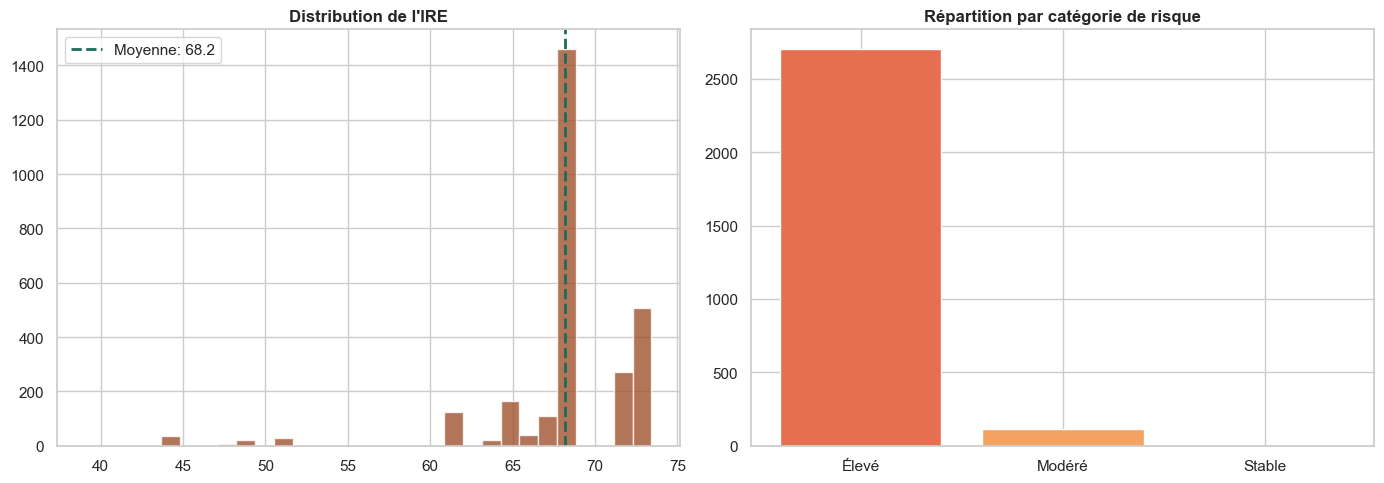

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['IRE'], bins=30, color='#A0522D', alpha=0.8, edgecolor='white')
axes[0].axvline(df['IRE'].mean(), color='#1A6B5A', linestyle='--', linewidth=2, label=f'Moyenne: {df["IRE"].mean():.1f}')
axes[0].set_title('Distribution de l\'IRE', fontweight='bold')
axes[0].legend()

cat_counts = df['categorie_risque'].value_counts()
couleurs = {'Stable': '#2d6a4f', 'Modéré': '#f4a261', 'Élevé': '#e76f51', 'Critique': '#d62828'}
axes[1].bar(cat_counts.index, cat_counts.values, color=[couleurs.get(c, 'gray') for c in cat_counts.index])
axes[1].set_title('Répartition par catégorie de risque', fontweight='bold')
plt.tight_layout()
plt.savefig('distribution_ire.png', dpi=150)
plt.show()

In [56]:

df_filtered = df[df['categorie_risque'] != 'Modéré'].copy()

print("Distribution après suppression:")
print(df_filtered['categorie_risque'].value_counts())

Distribution après suppression:
categorie_risque
Élevé     2700
Stable       1
Name: count, dtype: int64


In [57]:
FEATURES = ['surface_m2', 'lat', 'lon', 'humidite', 'densite_pop', 'protection_unesco']

X = df_filtered[FEATURES].copy()
y = df_filtered['categorie_risque'].copy()

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f'Classes: {dict(zip(le.classes_, range(len(le.classes_))))}')
print(f'Distribution: {dict(zip(*np.unique(y_encoded, return_counts=True)))}')

Classes: {'Stable': 0, 'Élevé': 1}
Distribution: {np.int64(0): np.int64(1), np.int64(1): np.int64(2700)}


In [58]:
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=FEATURES)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} bâtiments')
print(f'Test: {X_test.shape[0]} bâtiments')
print(f'Classes dans train: {np.unique(y_train, return_counts=True)}')
print(f'Classes dans test: {np.unique(y_test, return_counts=True)}')

Train: 2160 bâtiments
Test: 541 bâtiments
Classes dans train: (array([1]), array([2160]))
Classes dans test: (array([0, 1]), array([  1, 540]))


In [61]:

df_filtered = df.copy()

FEATURES = ['surface_m2', 'lat', 'lon', 'humidite', 'densite_pop', 'protection_unesco']

X = df_filtered[FEATURES].copy()
y = df_filtered['categorie_risque'].copy()

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f'Classes: {dict(zip(le.classes_, range(len(le.classes_))))}')
print(f'Distribution: {dict(zip(*np.unique(y_encoded, return_counts=True)))}')

# Imputer et scaler
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=FEATURES)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Split SANS stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

print(f'\nClasses dans train: {np.unique(y_train, return_counts=True)}')
print(f'Classes dans test: {np.unique(y_test, return_counts=True)}')

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('='*50)
print(' Régression Logistique')
print('='*50)
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score (macro): {f1_score(y_test, y_pred_lr, average="macro"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Classes: {'Modéré': 0, 'Stable': 1, 'Élevé': 2}
Distribution: {np.int64(0): np.int64(116), np.int64(1): np.int64(1), np.int64(2): np.int64(2700)}

Classes dans train: (array([0, 2]), array([  93, 2160]))
Classes dans test: (array([0, 1, 2]), array([ 23,   1, 540]))
 Régression Logistique
Accuracy: 0.9965
F1-Score (macro): 0.6519

Classification Report:
              precision    recall  f1-score   support

      Modéré       0.96      0.96      0.96        23
      Stable       0.00      0.00      0.00         1
       Élevé       1.00      1.00      1.00       540

    accuracy                           1.00       564
   macro avg       0.65      0.65      0.65       564
weighted avg       0.99      1.00      1.00       564



In [63]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('='*50)
print(' Random Forest')
print('='*50)
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score (macro): {f1_score(y_test, y_pred_rf, average="macro"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

 Random Forest
Accuracy: 0.9965
F1-Score (macro): 0.6519

Classification Report:
              precision    recall  f1-score   support

      Modéré       0.96      0.96      0.96        23
      Stable       0.00      0.00      0.00         1
       Élevé       1.00      1.00      1.00       540

    accuracy                           1.00       564
   macro avg       0.65      0.65      0.65       564
weighted avg       0.99      1.00      1.00       564



In [68]:
# Trouver les classes communes entre train et test
common_classes = np.intersect1d(np.unique(y_train), np.unique(y_test))
print(f"Classes communes: {common_classes}")

# Filtrer train et test pour garder seulement les classes communes
mask_train = np.isin(y_train, common_classes)
mask_test = np.isin(y_test, common_classes)

X_train_filtered = X_train[mask_train]
y_train_filtered = y_train[mask_train]
X_test_filtered = X_test[mask_test]
y_test_filtered = y_test[mask_test]

print(f"Train après filtrage: {X_train_filtered.shape[0]} samples")
print(f"Test après filtrage: {X_test_filtered.shape[0]} samples")
print(f"Classes dans train filtré: {np.unique(y_train_filtered)}")
print(f"Classes dans test filtré: {np.unique(y_test_filtered)}")

# Maintenant réencoder
le_fixed = LabelEncoder()
y_train_fixed = le_fixed.fit_transform(y_train_filtered)
y_test_fixed = le_fixed.transform(y_test_filtered)

print(f"Mapping: {dict(zip(le_fixed.classes_, range(len(le_fixed.classes_))))}")

# XGBoost
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42
    }
    model = xgb.XGBClassifier(**params, verbosity=0, eval_metric='logloss')
    score = cross_val_score(model, X_train_filtered, y_train_fixed, cv=3, scoring='accuracy')
    return score.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=False)

print(f' Meilleurs paramètres: {study.best_params}')

xgb_best = xgb.XGBClassifier(**study.best_params, verbosity=0, eval_metric='logloss', random_state=42)
xgb_best.fit(X_train_filtered, y_train_fixed)
y_pred_xgb = xgb_best.predict(X_test_filtered)

print('='*50)
print(' XGBoost (Optimisé)')
print('='*50)
print(f'Accuracy: {accuracy_score(y_test_fixed, y_pred_xgb):.4f}')
print(f'F1-Score (macro): {f1_score(y_test_fixed, y_pred_xgb, average="macro"):.4f}')
print('\nClassification Report:')

# Convertir les classes numpy en strings pour l'affichage
class_names = [str(c) for c in le_fixed.classes_]
print(classification_report(y_test_fixed, y_pred_xgb, target_names=class_names))

Classes communes: [0 2]
Train après filtrage: 2253 samples
Test après filtrage: 563 samples
Classes dans train filtré: [0 2]
Classes dans test filtré: [0 2]
Mapping: {np.int64(0): 0, np.int64(2): 1}
 Meilleurs paramètres: {'n_estimators': 106, 'max_depth': 6, 'learning_rate': 0.02226971872222943, 'subsample': 0.8760208898982053, 'colsample_bytree': 0.8258139104279211}
 XGBoost (Optimisé)
Accuracy: 0.9982
F1-Score (macro): 0.9884

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        23
           2       1.00      1.00      1.00       540

    accuracy                           1.00       563
   macro avg       1.00      0.98      0.99       563
weighted avg       1.00      1.00      1.00       563



 Comparaison des modèles (sur mêmes données):
               Modèle  Accuracy  F1-Score
Régression Logistique    0.0391    0.3259
        Random Forest    0.0391    0.3259
              XGBoost    0.9982    0.9884


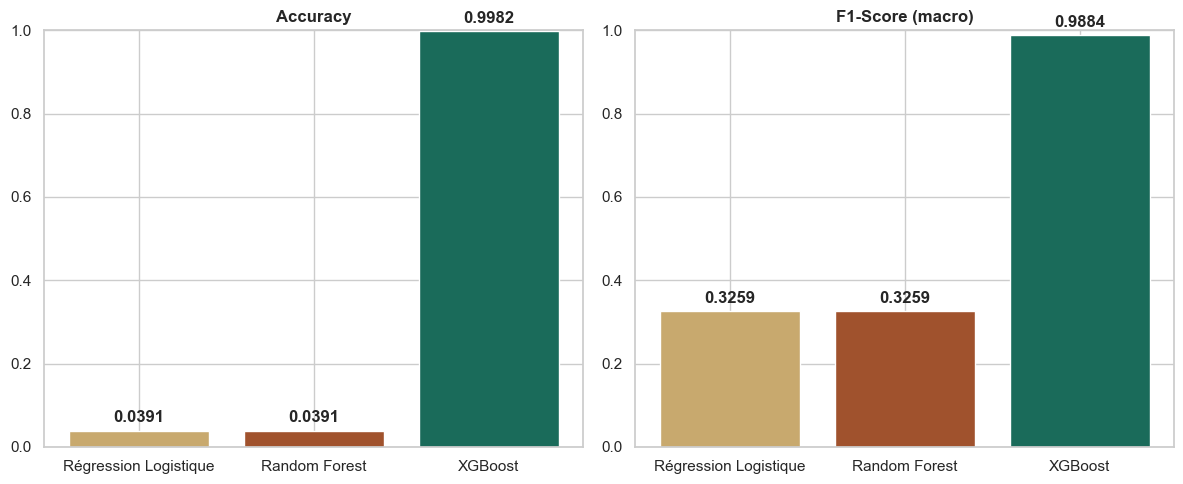

In [70]:
# Filtrer LR et RF sur les mêmes données que XGBoost
y_pred_lr_filtered = y_pred_lr[mask_test]
y_pred_rf_filtered = y_pred_rf[mask_test]

results = pd.DataFrame({
    'Modèle': ['Régression Logistique', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test_fixed, y_pred_lr_filtered), 
        accuracy_score(y_test_fixed, y_pred_rf_filtered), 
        accuracy_score(y_test_fixed, y_pred_xgb)
    ],
    'F1-Score': [
        f1_score(y_test_fixed, y_pred_lr_filtered, average='macro'), 
        f1_score(y_test_fixed, y_pred_rf_filtered, average='macro'), 
        f1_score(y_test_fixed, y_pred_xgb, average='macro')
    ]
})

print(' Comparaison des modèles (sur mêmes données):')
print(results.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(results['Modèle'], results['Accuracy'], color=['#C8A96E', '#A0522D', '#1A6B5A'])
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_ylim(0, 1)
for i, v in enumerate(results['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
    
axes[1].bar(results['Modèle'], results['F1-Score'], color=['#C8A96E', '#A0522D', '#1A6B5A'])
axes[1].set_title('F1-Score (macro)', fontweight='bold')
axes[1].set_ylim(0, 1)
for i, v in enumerate(results['F1-Score']):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
    
plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150)
plt.show()

In [72]:
# Utiliser les versions filtrées pour tous les modèles
y_pred_lr_filtered = y_pred_lr[mask_test]
y_pred_rf_filtered = y_pred_rf[mask_test]

# Déterminer le meilleur modèle
acc_lr = accuracy_score(y_test_fixed, y_pred_lr_filtered)
acc_rf = accuracy_score(y_test_fixed, y_pred_rf_filtered)
acc_xgb = accuracy_score(y_test_fixed, y_pred_xgb)

if acc_xgb >= max(acc_lr, acc_rf):
    best_model = xgb_best
    best_pred = y_pred_xgb
    best_name = 'XGBoost'
elif acc_rf >= max(acc_lr, acc_xgb):
    best_model = rf
    best_pred = y_pred_rf_filtered
    best_name = 'Random Forest'
else:
    best_model = lr
    best_pred = y_pred_lr_filtered
    best_name = 'Régression Logistique'

print(f' Meilleur modèle: {best_name}')
print(f'Accuracy: {max(acc_lr, acc_rf, acc_xgb):.4f}')

 Meilleur modèle: XGBoost
Accuracy: 0.9982


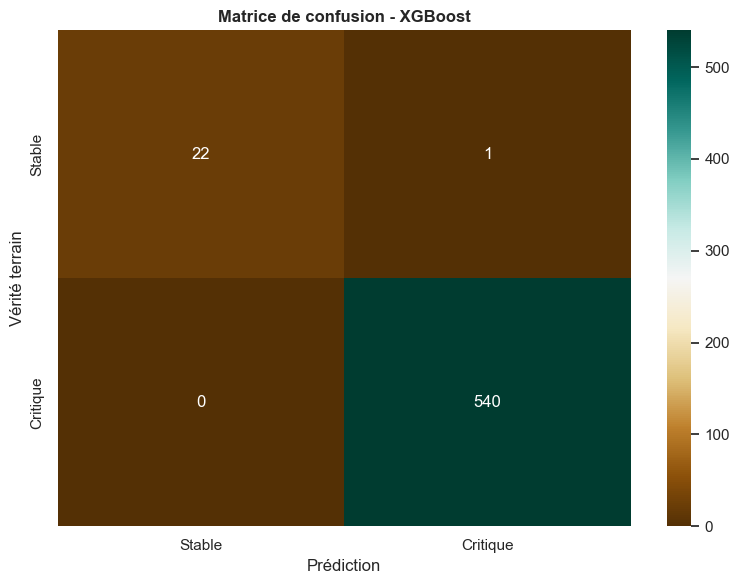

In [73]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_fixed, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='BrBG', 
            xticklabels=['Stable', 'Critique'], 
            yticklabels=['Stable', 'Critique'])
plt.title(f'Matrice de confusion - {best_name}', fontweight='bold')
plt.ylabel('Vérité terrain')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

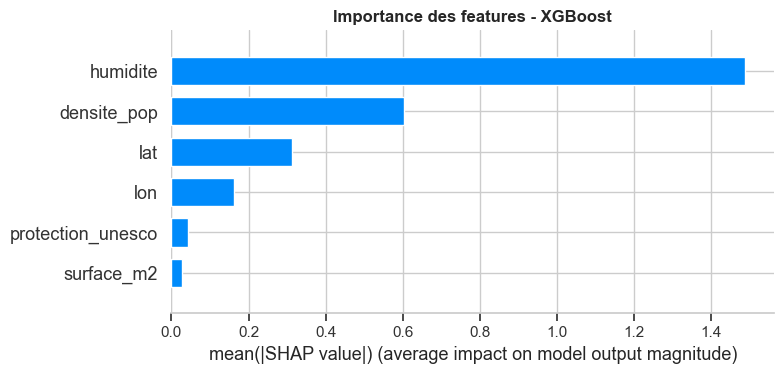

 Carte sauvegardée: carte_risque_finale.html


In [74]:
# SHAP pour le meilleur modèle
if best_name == 'XGBoost':
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_filtered)
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_filtered, feature_names=FEATURES, plot_type='bar', show=False)
    plt.title(f'Importance des features - {best_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_importance.png', dpi=150)
    plt.show()
elif best_name == 'Random Forest':
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_filtered)
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_filtered, feature_names=FEATURES, plot_type='bar', show=False)
    plt.title(f'Importance des features - {best_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_importance.png', dpi=150)
    plt.show()
else:
    # Pour Logistic Regression, utiliser coefficients
    coef_importance = np.abs(best_model.coef_[0])
    plt.figure(figsize=(10, 6))
    plt.barh(FEATURES, coef_importance, color='#A0522D')
    plt.title(f'Importance des features - {best_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_importance.png', dpi=150)
    plt.show()

# Carte de risque
couleurs_risque = {'Stable': '#2d6a4f', 'Élevé': '#e76f51', 'Critique': '#d62828'}

m = folium.Map(location=[34.0, 9.5], zoom_start=7, tiles='CartoDB positron')

sample_df = df_filtered if len(df_filtered) <= 1000 else df_filtered.sample(1000, random_state=42)

for _, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        color=couleurs_risque.get(row['categorie_risque'], 'gray'),
        fill=True,
        fill_opacity=0.7,
        tooltip=f"{row.get('name', 'Inconnu')}<br>Ville: {row['ville']}<br>IRE: {row['IRE']:.1f}<br>Risque: {row['categorie_risque']}"
    ).add_to(m)

legend_html = '''
<div style="position:fixed;bottom:30px;left:30px;background:white;padding:12px;border-radius:8px;box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
<b>🏛️ Niveau de risque IRE</b><br><br>
<span style="color:#2d6a4f">●</span> Stable (IRE &lt; 40)<br>
<span style="color:#e76f51">●</span> Élevé (60-75)<br>
<span style="color:#d62828">●</span> Critique (IRE &gt; 75)
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))
m.save('carte_risque_finale.html')
print(' Carte sauvegardée: carte_risque_finale.html')
m